
AUC SCORE: 0.7419192419323848


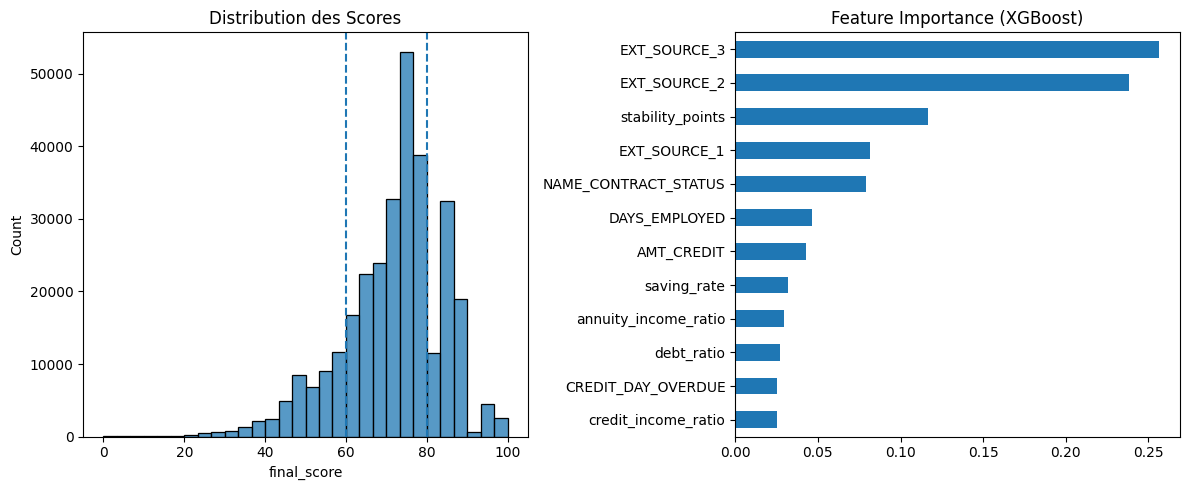


--- Répartition des Décisions ---
decision
RISQUE MOYEN     187555
CRÉDIT FACILE     70641
REFUS             49256
Name: count, dtype: int64

Sample predictions:
   final_score  risk_probability       decision
0    67.158082          0.313677   RISQUE MOYEN
1    88.677551          0.052898  CRÉDIT FACILE
2    74.259178          0.029633   RISQUE MOYEN
3    68.405618          0.063775   RISQUE MOYEN
4    72.175743          0.112970   RISQUE MOYEN


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# ==========================================
# 1. LOAD DATA
# ==========================================
train = pd.read_csv("./dataset/application_train.csv")
bureau = pd.read_csv("./dataset/bureau.csv")
prev = pd.read_csv("./dataset/previous_application.csv")

# ==========================================
# 2. FEATURE ENGINEERING (TUNISIAN PILLARS)
# ==========================================
def build_features(df, bureau, prev):
    df = df.copy()

    # ===== Capacity =====
    df['debt_ratio'] = (df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']) * 100
    df['saving_rate'] = ((df['AMT_INCOME_TOTAL'] - df['AMT_ANNUITY']) / df['AMT_INCOME_TOTAL']) * 100

    # ===== Stability =====
    stability_map = {
        'State servant': 25,
        'Pensioner': 20,
        'Commercial associate': 15,
        'Working': 10
    }
    df['stability_points'] = df['NAME_INCOME_TYPE'].map(stability_map).fillna(5)

    # ===== Bureau history =====
    bureau_agg = bureau.groupby('SK_ID_CURR')['CREDIT_DAY_OVERDUE'].max().reset_index()
    df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')
    df['CREDIT_DAY_OVERDUE'] = df['CREDIT_DAY_OVERDUE'].fillna(0)

    # ===== Behavior =====
    prev_ref = prev.groupby('SK_ID_CURR')['NAME_CONTRACT_STATUS'] \
        .apply(lambda x: (x == 'Refused').mean()) \
        .reset_index()

    df = df.merge(prev_ref, on='SK_ID_CURR', how='left')
    df['NAME_CONTRACT_STATUS'] = df['NAME_CONTRACT_STATUS'].fillna(0)

    # ===== EXT SOURCE (IMPORTANT) =====
    ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
    for col in ext_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # ===== Other useful features =====
    df['credit_income_ratio'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
    df['annuity_income_ratio'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

    return df


df_proc = build_features(train, bureau, prev)

# ==========================================
# 3. RULE-BASED SCORING (STRICT)
# ==========================================
def compute_rule_score(row):
    score = 0

    # Debt ratio
    if row['debt_ratio'] < 10:
        score += 30
    elif row['debt_ratio'] <= 25:
        score += 20
    elif row['debt_ratio'] <= 35:
        score += 10

    # Credit history
    if row['CREDIT_DAY_OVERDUE'] == 0:
        score += 20
    elif row['CREDIT_DAY_OVERDUE'] < 30:
        score += 5
    else:
        score -= 20

    # Saving
    if row['saving_rate'] >= 40:
        score += 15
    elif row['saving_rate'] >= 25:
        score += 10
    elif row['saving_rate'] >= 10:
        score += 5

    # Stability
    score += row['stability_points']

    # Behavior
    refusal_rate = row['NAME_CONTRACT_STATUS']
    if refusal_rate == 0:
        score += 10
    elif refusal_rate < 0.2:
        score += 5
    elif refusal_rate >= 0.4:
        score -= 15

    return score


df_proc['rule_score'] = df_proc.apply(compute_rule_score, axis=1)

# ==========================================
# 4. MACHINE LEARNING MODEL (STRONGER)
# ==========================================
features = [
    'debt_ratio',
    'saving_rate',
    'stability_points',
    'CREDIT_DAY_OVERDUE',
    'NAME_CONTRACT_STATUS',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
    'credit_income_ratio',
    'annuity_income_ratio',
    'AMT_CREDIT',
    'DAYS_EMPLOYED'
]

# Keep only existing columns
features = [f for f in features if f in df_proc.columns]

X = df_proc[features].fillna(0)
y = df_proc['TARGET']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# Evaluation
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

print("\n====================")
print(f"AUC SCORE: {auc}")
print("====================")

# ==========================================
# 5. HYBRID SCORING (BALANCED)
# ==========================================
df_proc['risk_probability'] = model.predict_proba(X)[:, 1]

# Less aggressive penalty (IMPORTANT)
df_proc['final_score'] = df_proc['rule_score'] - (df_proc['risk_probability'] * 25)

# Clip score
df_proc['final_score'] = np.clip(df_proc['final_score'], 0, 100)

# ==========================================
# 6. DECISION SEGMENTATION
# ==========================================
df_proc['decision'] = pd.cut(
    df_proc['final_score'],
    bins=[0, 60, 80, 100],
    labels=['REFUS', 'RISQUE MOYEN', 'CRÉDIT FACILE']
)

# ==========================================
# 7. VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 5))

# Score distribution
plt.subplot(1, 2, 1)
sns.histplot(df_proc['final_score'], bins=30)
plt.axvline(60, linestyle='--')
plt.axvline(80, linestyle='--')
plt.title('Distribution des Scores')

# Feature importance
plt.subplot(1, 2, 2)
pd.Series(model.feature_importances_, index=features) \
    .sort_values() \
    .plot(kind='barh')

plt.title('Feature Importance (XGBoost)')

plt.tight_layout()
plt.show()

# ==========================================
# 8. FINAL OUTPUT
# ==========================================
print("\n--- Répartition des Décisions ---")
print(df_proc['decision'].value_counts())

print("\nSample predictions:")
print(df_proc[['final_score', 'risk_probability', 'decision']].head())

Model                | Best Train AUC  | Test AUC  
--------------------------------------------------
Logistic Regression  | 0.7085          | 0.7147
Random Forest        | 0.7299          | 0.7342


c:\Users\arfao\Desktop\scoring_pipline\scoring_engine\lib\site-packages\xgboost\training.py:200: UserWarning: [05:10:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost              | 0.7385          | 0.7414


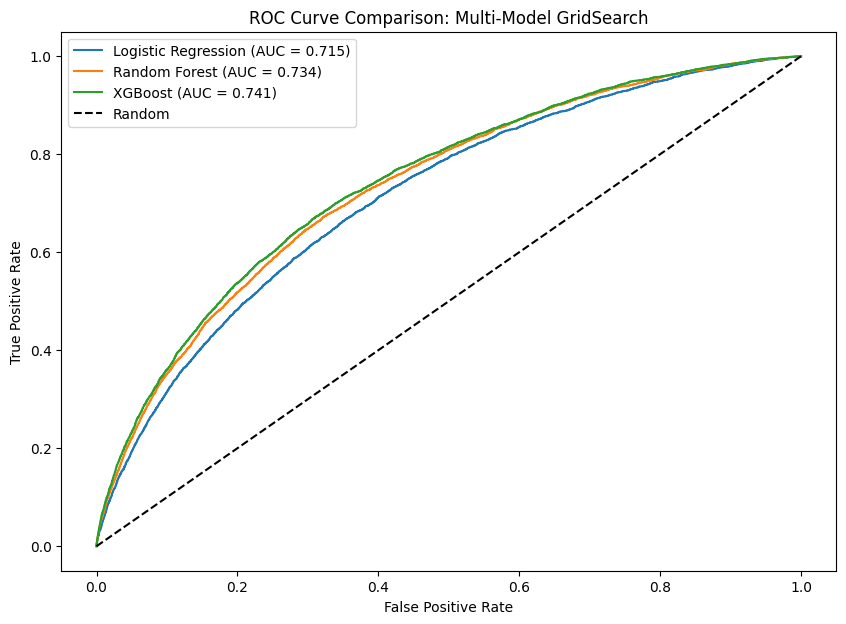


🏆 WINNER: XGBoost with AUC: 0.7414
Best Configuration: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__scale_pos_weight': 1}


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve

# 1. SETUP CROSS-VALIDATION AND SCALING
# StratifiedKFold ensures each fold has the same % of high-risk cases
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate class imbalance for XGBoost
ratio = np.sum(y_train == 0) / np.sum(y_train == 1)

# 2. DEFINE THE MODELS AND THEIR HYPERPARAMETER GRIDS
# Note: Parameter names must start with 'clf__' to match the Pipeline step
configs = {
    'Logistic Regression': {
        'model': LogisticRegression(solver='liblinear', random_state=42),
        'params': {
            'clf__C': [0.1, 1, 10],
            'clf__class_weight': [None, 'balanced']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'clf__n_estimators': [100, 200],
            'clf__max_depth': [5, 10, None],
            'clf__class_weight': ['balanced', 'balanced_subsample']
        }
    },
    'XGBoost': {
        'model': XGBClassifier(eval_metric='auc', use_label_encoder=False, random_state=42),
        'params': {
            'clf__n_estimators': [100, 200],
            'clf__learning_rate': [0.01, 0.05, 0.1],
            'clf__max_depth': [3, 5, 7],
            'clf__scale_pos_weight': [1, ratio] # Vital for AUC optimization
        }
    }
}

# 3. EXECUTE GRID SEARCH FOR EACH MODEL
results = []
plt.figure(figsize=(10, 7))

print(f"{'Model':<20} | {'Best Train AUC':<15} | {'Test AUC':<10}")
print("-" * 50)

for name, config in configs.items():
    # Create Pipeline: Scaling -> Model
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', config['model'])
    ])
    
    # GridSearch on the Pipeline
    grid = GridSearchCV(pipeline, config['params'], cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    # Evaluation
    best_model = grid.best_estimator_
    y_proba = best_model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_proba)
    
    results.append({'Model': name, 'Best_Params': grid.best_params_, 'Test_AUC': test_auc})
    
    # Plotting ROC Curve for comparison
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {test_auc:.3f})")
    print(f"{name:<20} | {grid.best_score_:.4f}          | {test_auc:.4f}")

# 4. FINALIZE COMPARISON
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Multi-Model GridSearch')
plt.legend()
plt.show()

# Find the absolute winner
winner = max(results, key=lambda x: x['Test_AUC'])
print(f"\n🏆 WINNER: {winner['Model']} with AUC: {winner['Test_AUC']:.4f}")
print(f"Best Configuration: {winner['Best_Params']}")

In [21]:
import joblib

# 'grid' was your GridSearchCV object from the previous step
best_pipeline = grid.best_estimator_ 

# Save the model to a file
joblib.dump(best_pipeline, 'tunisian_credit_model.pkl')
print("Model saved successfully!")

Model saved successfully!


In [23]:
# Run this in your notebook to get the list
print(X_train.columns.tolist())

['debt_ratio', 'saving_rate', 'stability_points', 'CREDIT_DAY_OVERDUE', 'NAME_CONTRACT_STATUS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'credit_income_ratio', 'annuity_income_ratio', 'AMT_CREDIT', 'DAYS_EMPLOYED']
